# Fase 2 — Notebook 3: validación técnica y resultados

**Proyecto:** Sobreduración en la titulación de la educación superior chilena (2020–2025)
**Equipo:** «Integrante 1», «Integrante 2», «Integrante 3»  ·  **Grupo:** «N»

---

**Objetivo de este notebook (OE6).** Verificar técnicamente el conjunto
analítico producido en el notebook anterior y presentar los resultados
exploratorios que responden a las preguntas planteadas en la Fase 1.

La verificación se realiza en tres niveles: **reglas de validación** sobre el
conjunto completo, **pruebas automatizadas** sobre las funciones del pipeline y
**comprobación de reproducibilidad** re-ejecutando el flujo de extremo a extremo.

## 1. Entorno y carga del conjunto analítico

In [1]:
# Celda de arranque: hace importable el paquete `src` sin instalar el proyecto
# y funciona igual si el notebook se abre desde la raiz o desde su subcarpeta.
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from src import config

print("Raiz del proyecto:", RAIZ)
for clave, valor in config.describir_entorno().items():
    print(f"  {clave:12s} {valor}")

Raiz del proyecto: C:\Magister Ciencia de Datos\Programacion para la Ciencia\Semana 1\Sumativa 1\proyecto-titulados
  python       3.14.7
  plataforma   Windows-11-10.0.26200-SP0
  ejecutable   C:\Users\santunez\AppData\Local\Programs\Python\Python314\python.exe
  numpy        2.5.2
  pandas       3.0.5
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


In [2]:
from src import pipeline, transformacion as tr, validacion, viz

viz.aplicar_estilo()

df = pipeline.cargar_analitico()
print(f"Conjunto analítico: {len(df):,} registros x {df.shape[1]} columnas")
print(f"Cobertura: {int(df['cat_periodo'].min())}-{int(df['cat_periodo'].max())}")

Conjunto analítico: 1,246,760 registros x 47 columnas
Cobertura: 2020-2025


## 2. Validación mediante motor de reglas

La verificación no se deja a inspecciones visuales: está implementada como un
motor de reglas en `src/validacion.py`. Cada regla es un objeto con nombre,
descripción, severidad y una función de comprobación; el validador las ejecuta
todas y entrega una tabla de veredictos.

Las reglas **críticas** invalidan el conjunto si fallan; las **advertencias**
señalan comportamientos que deben documentarse pero no impiden continuar.

In [3]:
validador = validacion.validador_estandar()
reporte = validador.ejecutar(df)

print(reporte[["regla", "severidad", "estado", "detalle"]].to_string(index=False))
print("\n" + validador.resumen())

reporte.to_csv(config.TABLES_DIR / "reporte_validacion.csv", index=False)
assert validador.aprobado, "El conjunto no supera las reglas críticas"

                    regla   severidad   estado                                                                                          detalle
         dataset_no_vacio     critica     PASA                                                         1,246,760 filas en el dataset analitico.
       columnas_derivadas     critica     PASA                                                         Todas las variables derivadas presentes.
       sin_nulos_criticos     critica     PASA                                                              Sin nulos en las columnas criticas.
      rango_duracion_real     critica     PASA                                     Duracion real dentro de [1, 40] semestres; 0 fuera de rango.
               rango_edad     critica     PASA                                         Edad de titulacion dentro de [15, 90]; 0 fuera de rango.
           dominio_genero     critica     PASA                                                          Valores observados: ['Hombre', '

### 2.1 Análisis de la advertencia detectada

La única regla no aprobada es de severidad *advertencia*: en cerca de un 18 % de
los registros el año del proceso (`cat_periodo`) no coincide con el año de la
fecha del título. La comprobación siguiente muestra que se trata de un desfase
administrativo conocido y no de un error de procesamiento: son títulos obtenidos
al cierre de un año que el sistema informa en el proceso siguiente, o al revés.

In [4]:
desfase = (df["cat_periodo"].astype(int) - df["anio_titulo"].astype(int))
resumen_desfase = desfase.value_counts().sort_index()
resumen_desfase = pd.DataFrame({
    "desfase_anios": resumen_desfase.index,
    "registros": resumen_desfase.to_numpy(),
    "porcentaje": (100 * resumen_desfase / len(df)).round(2).to_numpy(),
})
print(resumen_desfase.to_string(index=False))

meses_desfasados = df.loc[desfase != 0, "mes_titulo"].value_counts().sort_index()
print("\nMes de titulación de los registros desfasados:")
print(meses_desfasados.to_string())
print("\nEl desfase se concentra en los meses extremos del año, lo que confirma")
print("que corresponde al calendario administrativo del proceso y no a un error.")

 desfase_anios  registros  porcentaje
            -1     230563       18.49
             0    1016197       81.51

Mes de titulación de los registros desfasados:
mes_titulo
1    163895
2     66668

El desfase se concentra en los meses extremos del año, lo que confirma
que corresponde al calendario administrativo del proceso y no a un error.


## 3. Pruebas automatizadas del pipeline

La suite cubre casos normales, casos límite (bordes de cada regla) y
excepciones (entradas inválidas que deben fallar de forma controlada). Se
ejecuta desde el notebook para dejar la evidencia dentro del documento.

In [5]:
import subprocess

resultado = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v", "--no-header", "-q"],
    cwd=RAIZ, capture_output=True, text=True,
)
print(resultado.stdout[-3000:])
print("Código de salida:", resultado.returncode)
assert resultado.returncode == 0, "Las pruebas automatizadas no pasaron"

============================= test session starts =============================
collected 22 items

tests\test_pipeline.py ......................                            [100%]

============================= 22 passed in 2.05s ==============================

Código de salida: 0


## 4. Comprobación de reproducibilidad de extremo a extremo

Se vuelve a ejecutar el pipeline completo desde el consolidado y se comparan los
resultados con el conjunto guardado. Si ambos coinciden, el flujo es
determinista: la misma entrada produce siempre la misma salida.

In [6]:
df_reejecutado, bitacora_re, reporte_re = pipeline.ejecutar(guardar=False, verboso=False)

comparacion = pd.DataFrame([
    {"indicador": "Registros", "guardado": len(df), "reejecutado": len(df_reejecutado)},
    {"indicador": "Columnas", "guardado": df.shape[1], "reejecutado": df_reejecutado.shape[1]},
    {"indicador": "Suma de sobreduración",
     "guardado": int(df["sobreduracion_sem"].sum()),
     "reejecutado": int(df_reejecutado["sobreduracion_sem"].sum())},
    {"indicador": "Titulación oportuna (n)",
     "guardado": int(df["titulacion_oportuna"].sum()),
     "reejecutado": int(df_reejecutado["titulacion_oportuna"].sum())},
])
comparacion["coincide"] = comparacion["guardado"] == comparacion["reejecutado"]
print(comparacion.to_string(index=False))

assert comparacion["coincide"].all(), "El pipeline no es determinista"
print("\nReproducibilidad verificada: la re-ejecución produce resultados idénticos.")

              indicador  guardado  reejecutado  coincide
              Registros   1246760      1246760      True
               Columnas        47           47      True
  Suma de sobreduración   3441408      3441408      True
Titulación oportuna (n)    236528       236528      True

Reproducibilidad verificada: la re-ejecución produce resultados idénticos.


---

# 5. Resultados

Las secciones siguientes responden, una a una, las preguntas formuladas en la
Fase 1. Todas las tablas se generan con la función `tabla_agregada`, que descarta
los grupos con menos de 30 casos para no publicar promedios calculados sobre
poblaciones mínimas.

## 5.1 Pregunta 1 — ¿Cuánta sobreduración hay y cuántos se titulan a tiempo?

In [7]:
indicadores = pd.DataFrame([
    {"indicador": "Duración teórica media del plan (semestres)",
     "valor": round(df["dur_total_carr"].mean(), 2)},
    {"indicador": "Duración real media (semestres)",
     "valor": round(df["duracion_real_sem"].mean(), 2)},
    {"indicador": "Sobreduración media (semestres)",
     "valor": round(df["sobreduracion_sem"].mean(), 2)},
    {"indicador": "Sobreduración mediana (semestres)",
     "valor": float(df["sobreduracion_sem"].median())},
    {"indicador": "Índice de duración medio (real/teórica)",
     "valor": round(df["indice_duracion"].mean(), 2)},
    {"indicador": "Titulación oportuna (%)",
     "valor": round(100 * df["titulacion_oportuna"].mean(), 1)},
    {"indicador": "Edad media al titularse (años)",
     "valor": round(df["edad_titulacion"].mean(), 1)},
])
print(indicadores.to_string(index=False))

distribucion = (100 * df["categoria_rezago"].value_counts(normalize=True)).round(1)
print("\nDistribución por categoría de rezago (%):")
print(distribucion.reindex(["Oportuna", "Rezago leve", "Rezago moderado",
                            "Rezago severo"]).to_string())

                                  indicador  valor
Duración teórica media del plan (semestres)   7.39
            Duración real media (semestres)  10.15
            Sobreduración media (semestres)   2.76
          Sobreduración mediana (semestres)   1.00
    Índice de duración medio (real/teórica)   1.43
                    Titulación oportuna (%)  19.00
             Edad media al titularse (años)  27.90

Distribución por categoría de rezago (%):
categoria_rezago
Oportuna           19.0
Rezago leve        44.3
Rezago moderado    16.4
Rezago severo      20.4


> **Hallazgo 1.** Solo **19,0 %** de los titulados de pregrado egresa dentro del
> plazo comprometido por su plan de estudios. La sobreduración media es de
> **2,76 semestres** —cerca de un año y medio adicional— y el índice de duración
> medio de **1,43** indica que una carrera toma en promedio un 43 % más de tiempo
> del planificado. Uno de cada cinco titulados (20,4 %) acumula un rezago severo,
> superior a dos años.

## 5.2 Evolución anual y efecto de la pandemia

 cat_periodo  titulados  media  mediana  p25  p75  pct_oportuna
        2020     159491    2.5      1.0  1.0  3.0          17.9
        2021     219642   2.96      2.0  1.0  4.0          15.2
        2022     217356   2.89      2.0  1.0  4.0          18.4
        2023     217784   2.96      1.0  1.0  4.0          18.7
        2024     212103   2.68      1.0  1.0  3.0          21.1
        2025     220384    2.5      1.0  1.0  3.0          22.3


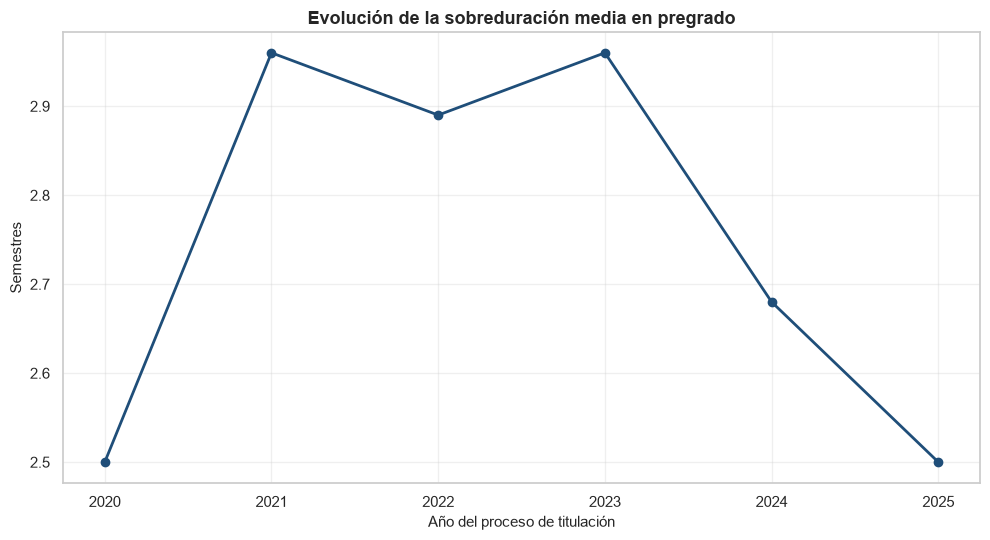

In [8]:
por_anio = tr.tabla_agregada(df, "cat_periodo").sort_values("cat_periodo")
print(por_anio.to_string(index=False))

serie = por_anio.set_index("cat_periodo")[["media", "pct_oportuna"]]
fig = viz.serie_temporal(
    serie[["media"]].rename(columns={"media": "Sobreduración media (semestres)"}),
    "Evolución de la sobreduración media en pregrado",
    "Semestres",
    nombre_archivo="f2_3_evolucion_sobreduracion",
)

Variación 2021-2025 en titulación oportuna: +7.1 puntos porcentuales


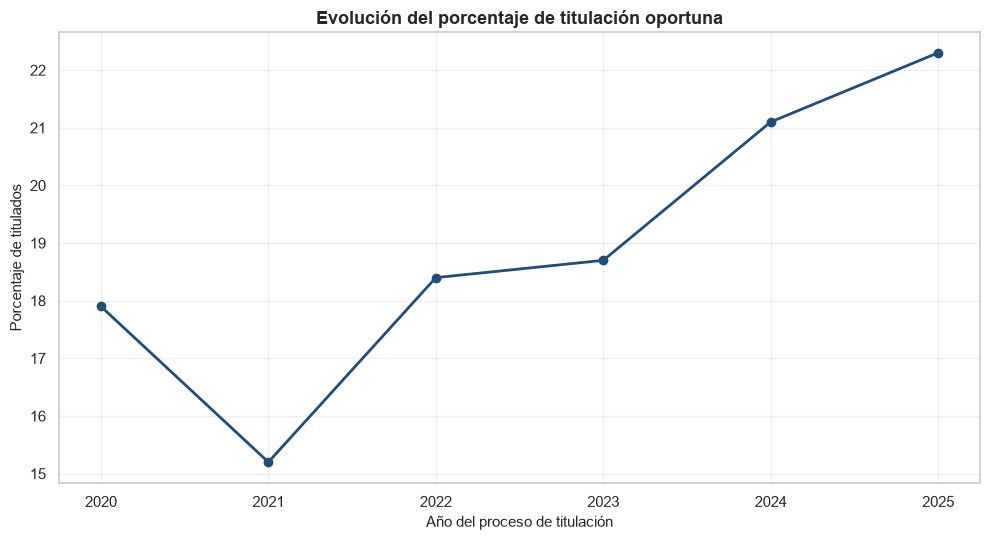

In [9]:
fig = viz.serie_temporal(
    serie[["pct_oportuna"]].rename(columns={"pct_oportuna": "Titulación oportuna (%)"}),
    "Evolución del porcentaje de titulación oportuna",
    "Porcentaje de titulados",
    nombre_archivo="f2_3_evolucion_oportuna",
)
print("Variación 2021-2025 en titulación oportuna: "
      f"{serie.loc[2025, 'pct_oportuna'] - serie.loc[2021, 'pct_oportuna']:+.1f} puntos porcentuales")

> **Hallazgo 2.** El año 2020 registra 159.491 titulados de pregrado, un 27,4 %
> menos que 2021: la suspensión de la actividad presencial desplazó exámenes de
> grado y ceremonias hacia el año siguiente. Tras ese ajuste, la titulación
> oportuna mejora de forma sostenida, desde 15,2 % en 2021 hasta 22,3 % en 2025
> (+7,1 puntos porcentuales).

## 5.3 Pregunta 2 — Diferencias por área de conocimiento y tipo de institución

        area_conocimiento  titulados  media  mediana  p25  p75  pct_oportuna
                  Derecho      28748   5.77      4.0  2.0  8.0           8.7
         Ciencias Básicas      13505    4.5      4.0  2.0  6.0           6.3
               Tecnología     317385   3.63      2.0  1.0  5.0          14.1
             Agropecuaria      30915   3.57      2.0  1.0  5.0          10.7
              Humanidades       7813   2.72      2.0  1.0  4.0          15.9
      Arte y Arquitectura      54065   2.65      1.0  1.0  3.0          19.0
Administración y Comercio     285186   2.42      1.0  1.0  3.0          21.7
                    Salud     232468   2.37      1.0  1.0  3.0          21.9
        Ciencias Sociales     129637   2.01      1.0  1.0  3.0          21.8
                Educación     147038   1.93      1.0  1.0  2.0          22.4


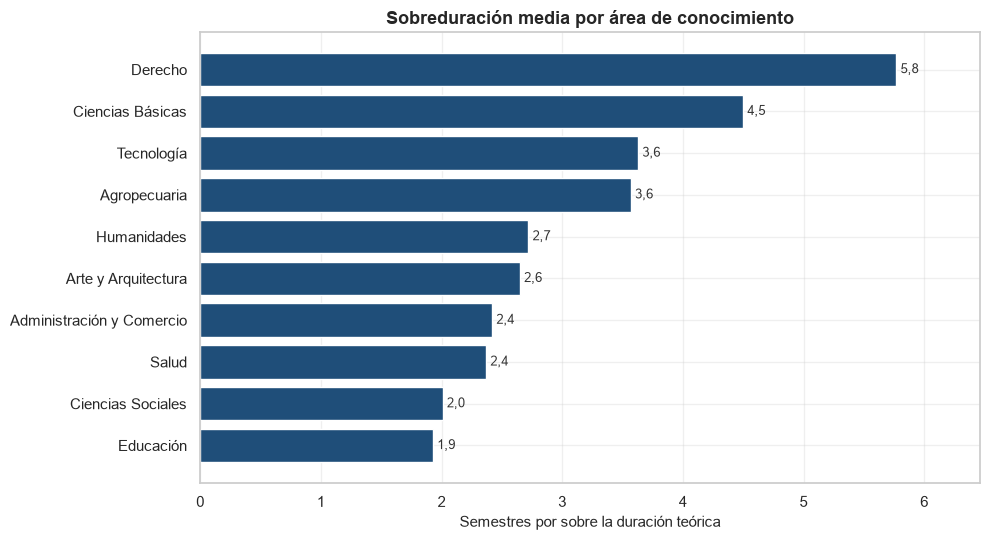

In [10]:
por_area = tr.tabla_agregada(df, "area_conocimiento")
print(por_area.to_string(index=False))

fig = viz.barras(
    por_area.set_index("area_conocimiento")["media"],
    "Sobreduración media por área de conocimiento",
    "Semestres por sobre la duración teórica",
    nombre_archivo="f2_3_sobreduracion_area",
)

                 tipo_inst_1  titulados  media  mediana  p25  p75  pct_oportuna
               Universidades     569497   3.32      2.0  1.0  5.0          12.8
Centros de Formación Técnica     214592   2.83      1.0  1.0  3.0          13.9
    Institutos Profesionales     462671   2.05      1.0  0.0  3.0          28.9


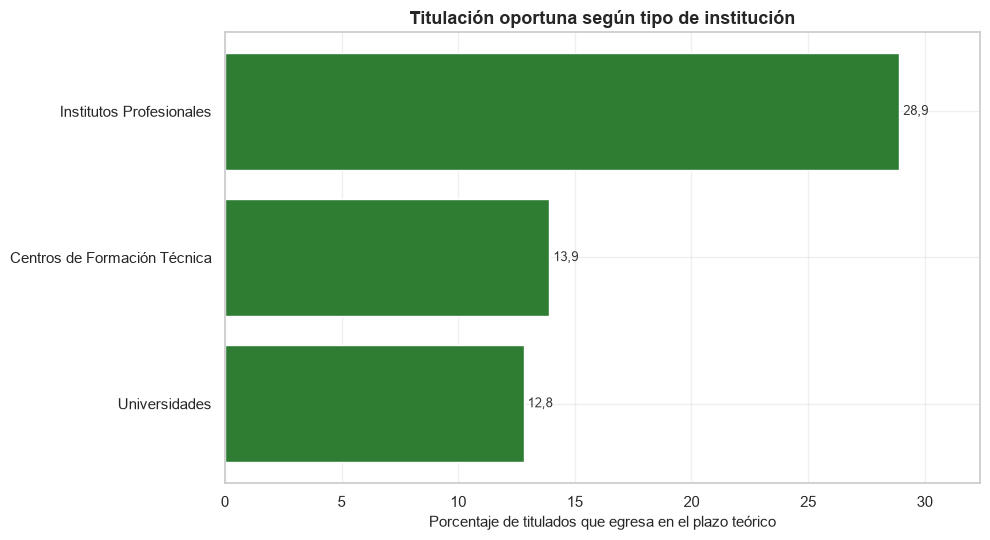

In [11]:
por_institucion = tr.tabla_agregada(df, "tipo_inst_1")
print(por_institucion.to_string(index=False))

fig = viz.barras(
    por_institucion.set_index("tipo_inst_1")["pct_oportuna"],
    "Titulación oportuna según tipo de institución",
    "Porcentaje de titulados que egresa en el plazo teórico",
    color=config.PALETA["acento"],
    nombre_archivo="f2_3_oportuna_institucion",
)

tipo_inst_1                Centros de Formación Técnica  Institutos Profesionales  Universidades
area_conocimiento                                                                               
Administración y Comercio                          2.87                      1.87           3.02
Agropecuaria                                       2.59                      2.48            4.7
Arte y Arquitectura                                2.71                      1.97           3.44
Ciencias Básicas                                   4.15                      3.54           4.66
Ciencias Sociales                                  1.03                      1.63           2.34
Derecho                                            2.52                       1.4           6.49
Educación                                          1.56                      1.46           2.36
Humanidades                                        1.21                       2.2           2.86
Salud                         

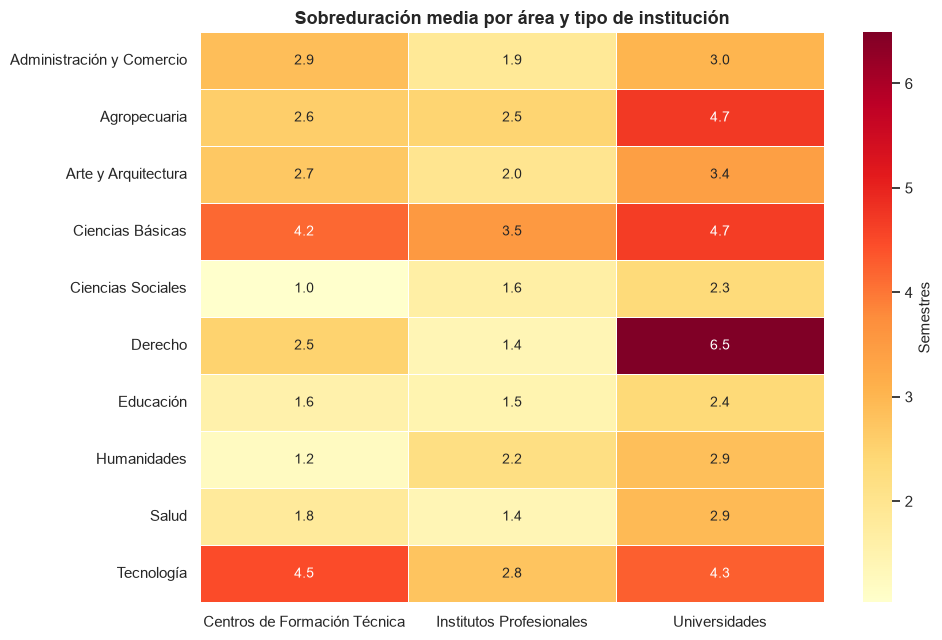

In [12]:
cruce = df.pivot_table(
    index="area_conocimiento", columns="tipo_inst_1",
    values="sobreduracion_sem", aggfunc="mean", observed=True,
).round(2)

fig = viz.mapa_calor(
    cruce,
    "Sobreduración media por área y tipo de institución",
    "Semestres",
    nombre_archivo="f2_3_mapa_area_institucion",
)
print(cruce.to_string())

> **Hallazgo 3.** La sobreduración es marcadamente heterogénea: **Derecho**
> (5,77 semestres) y **Ciencias Básicas** (4,50) casi triplican a **Educación**
> (1,93). En Derecho solo el 8,7 % se titula a tiempo, frente al 22,4 % en
> Educación.
>
> Por tipo de institución, las **universidades** promedian 3,32 semestres de
> sobreduración y apenas un 12,8 % de titulación oportuna, mientras que los
> **institutos profesionales** promedian 2,05 y alcanzan un 28,9 %. La brecha se
> explica en parte por la extensión de los planes universitarios y por sus
> procesos de titulación (tesis, exámenes de grado, prácticas prolongadas), que
> en los IP suelen estar incorporados al plan regular.

## 5.4 Pregunta 3 — Brecha de género

In [13]:
por_genero = tr.tabla_agregada(df, "genero")
print(por_genero.to_string(index=False))

brecha_global = (
    df.loc[df["genero"] == "Mujer", "sobreduracion_sem"].mean()
    - df.loc[df["genero"] == "Hombre", "sobreduracion_sem"].mean()
)
print(f"\nBrecha global (mujeres - hombres): {brecha_global:.2f} semestres")

genero  titulados  media  mediana  p25  p75  pct_oportuna
Hombre     542694   3.29      2.0  1.0  5.0          16.0
 Mujer     704066   2.35      1.0  1.0  3.0          21.3

Brecha global (mujeres - hombres): -0.93 semestres


        area_conocimiento  Hombre  Mujer  total  pct_mujeres  brecha_sobreduracion
                Educación   29324 117714 147038         80.1                 -0.88
                    Salud   48730 183738 232468         79.0                 -0.44
        Ciencias Sociales   35735  93902 129637         72.4                 -0.55
              Humanidades    2767   5046   7813         64.6                  -0.3
      Arte y Arquitectura   19748  34317  54065         63.5                 -0.97
Administración y Comercio  115801 169385 285186         59.4                 -0.42
                  Derecho   12376  16372  28748         57.0                 -0.66
             Agropecuaria   13415  17500  30915         56.6                 -0.52
         Ciencias Básicas    7675   5830  13505         43.2                 -0.14
               Tecnología  257123  60262 317385         19.0                 -0.18


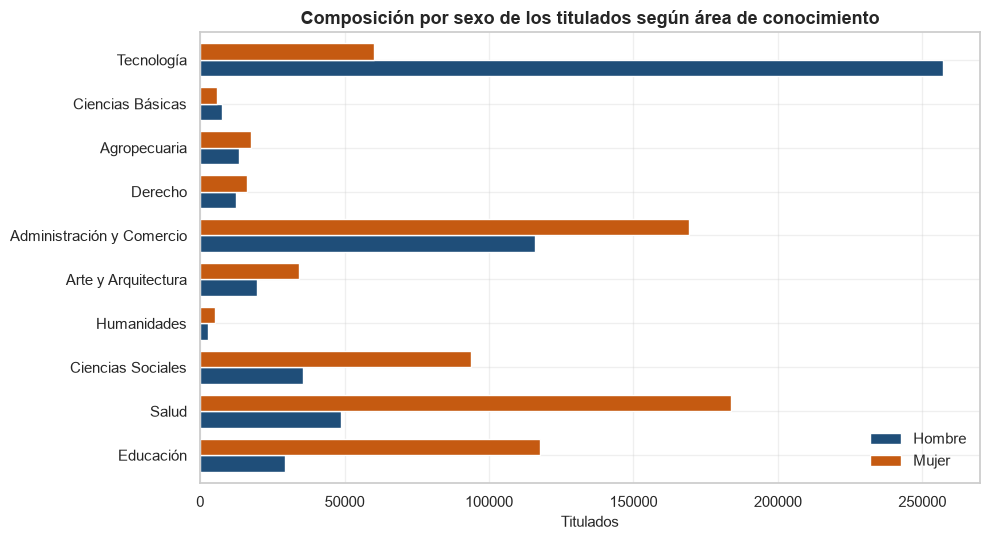

In [14]:
brecha_area = tr.razon_feminidad(df, "area_conocimiento")
print(brecha_area.to_string(index=False))

fig = viz.barras_agrupadas(
    brecha_area.set_index("area_conocimiento")[["Hombre", "Mujer"]],
    "Composición por sexo de los titulados según área de conocimiento",
    "Titulados",
    nombre_archivo="f2_3_composicion_genero_area",
)

genero                     Hombre  Mujer
area_conocimiento                       
Administración y Comercio    2.67   2.25
Agropecuaria                 3.87   3.35
Arte y Arquitectura          3.27    2.3
Ciencias Básicas             4.56   4.42
Ciencias Sociales            2.41   1.86
Derecho                      6.14   5.48
Educación                    2.63   1.75
Humanidades                  2.91   2.62
Salud                        2.72   2.28
Tecnología                   3.67   3.48


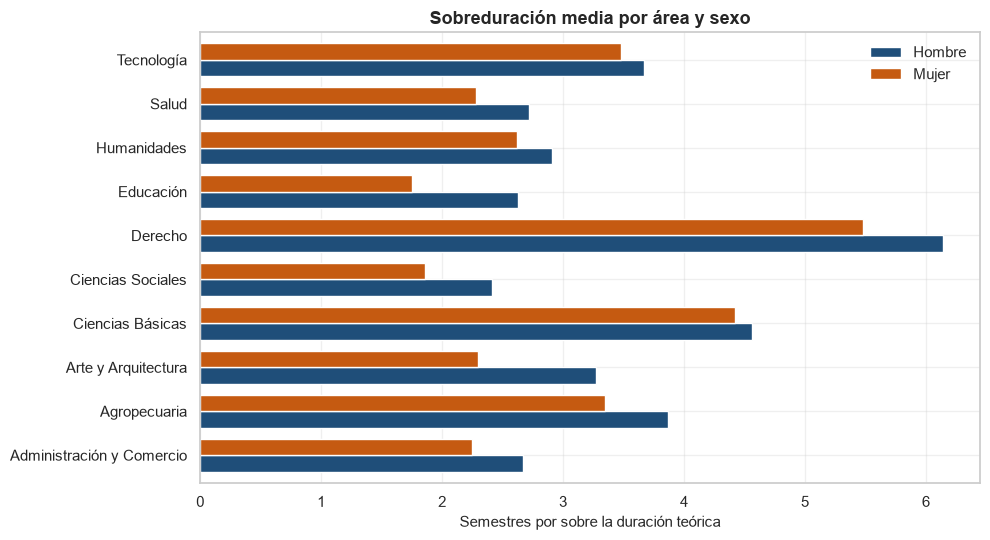

In [15]:
medias_genero = df.pivot_table(
    index="area_conocimiento", columns="genero",
    values="sobreduracion_sem", aggfunc="mean", observed=True,
).round(2)

fig = viz.barras_agrupadas(
    medias_genero,
    "Sobreduración media por área y sexo",
    "Semestres por sobre la duración teórica",
    nombre_archivo="f2_3_sobreduracion_genero_area",
)
print(medias_genero.to_string())

> **Hallazgo 4.** Las mujeres se titulan sistemáticamente antes: 2,35 semestres
> de sobreduración frente a 3,29 de los hombres, una brecha de **0,94 semestres**
> a favor de las mujeres, y 21,3 % frente a 16,0 % de titulación oportuna. La
> ventaja femenina se observa en **las diez áreas de conocimiento**, sin
> excepción, y es mayor en Arte y Arquitectura (−0,97) y Educación (−0,88).
>
> La composición por sexo, en cambio, está fuertemente segregada: las mujeres son
> el 80,1 % de los titulados en Educación y el 79,0 % en Salud, pero solo el
> 19,0 % en Tecnología, el área con mayor volumen de titulados del sistema.

## 5.5 Pregunta 4 — Modalidad de estudio y educación a distancia

In [16]:
por_modalidad = tr.tabla_agregada(df, "modalidad")
print(por_modalidad.to_string(index=False))
print()
print(tr.tabla_agregada(df, "jornada").to_string(index=False))

     modalidad  titulados  media  mediana  p25  p75  pct_oportuna
    Presencial    1126649   2.86      2.0  1.0  4.0          17.2
 No Presencial      97184   1.84      1.0  0.0  2.0          34.6
Semipresencial      22927   1.74      1.0 -1.0  2.0          39.7

       jornada  titulados  media  mediana  p25  p75  pct_oportuna
    Vespertina     311614   2.94      1.0  1.0  4.0          22.1
        Diurna     817860   2.84      2.0  1.0  4.0          15.3
   A Distancia      97184   1.84      1.0  0.0  2.0          34.6
          Otra       6836   1.83      1.0  0.0  2.0          29.9
Semipresencial      13266   1.06      0.0 -1.0  2.0          51.6


modalidad    No Presencial  Presencial  Semipresencial
cat_periodo                                           
2020                   4.7        91.5             3.8
2021                   5.1        92.5             2.4
2022                   6.5        91.5             2.0
2023                   8.5        90.1             1.4
2024                  10.0        89.0             1.0
2025                  11.2        87.9             0.9

Titulados no presenciales: 7,492 en 2020 -> 24,697 en 2025 (230% de aumento)


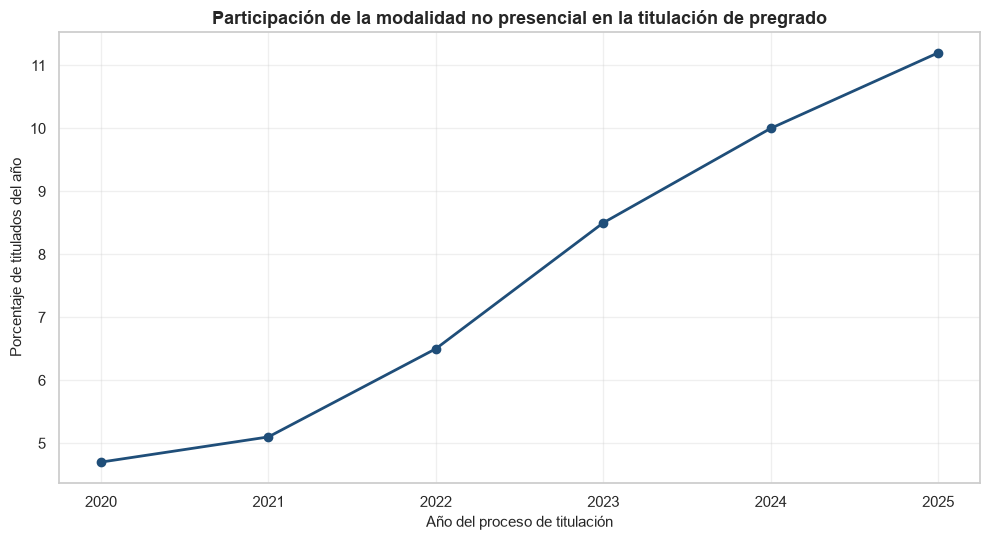

In [17]:
evolucion_modalidad = pd.crosstab(
    df["cat_periodo"], df["modalidad"], normalize="index"
).mul(100).round(1)

fig = viz.serie_temporal(
    evolucion_modalidad[["No Presencial"]],
    "Participación de la modalidad no presencial en la titulación de pregrado",
    "Porcentaje de titulados del año",
    nombre_archivo="f2_3_evolucion_no_presencial",
)
print(evolucion_modalidad.to_string())

volumen = pd.crosstab(df["cat_periodo"], df["modalidad"])["No Presencial"]
print(f"\nTitulados no presenciales: {volumen.loc[2020]:,} en 2020 -> "
      f"{volumen.loc[2025]:,} en 2025 "
      f"({100*(volumen.loc[2025]/volumen.loc[2020]-1):.0f}% de aumento)")

In [18]:
perfil_modalidad = df.groupby("modalidad", observed=True).agg(
    titulados=("edad_titulacion", "size"),
    edad_media=("edad_titulacion", "mean"),
    edad_mediana=("edad_titulacion", "median"),
    sobreduracion_media=("sobreduracion_sem", "mean"),
    pct_oportuna=("titulacion_oportuna", "mean"),
    duracion_teorica_media=("dur_total_carr", "mean"),
).round(2)
perfil_modalidad["pct_oportuna"] = (100 * perfil_modalidad["pct_oportuna"]).round(1)
print(perfil_modalidad.to_string())

                titulados  edad_media  edad_mediana  sobreduracion_media  pct_oportuna  duracion_teorica_media
modalidad                                                                                                     
No Presencial       97184       37.38          36.0                 1.84          35.0                    5.51
Presencial        1126649       26.99          25.0                 2.86          17.0                    7.59
Semipresencial      22927       35.02          33.0                 1.74          40.0                    5.89


> **Hallazgo 5.** La modalidad no presencial pasó de 4,7 % de los titulados de
> pregrado en 2020 a 11,2 % en 2025, triplicando su volumen (de 7.492 a 24.697
> titulados, +230 %). Quienes egresan por esta vía muestran **menos**
> sobreduración (1,84 frente a 2,86 semestres) y casi el doble de titulación
> oportuna (34,6 % frente a 17,2 %).
>
> La comparación, sin embargo, **no debe leerse como un efecto de la modalidad**:
> el perfil es distinto. La edad media de titulación en modalidad no presencial
> es de 37,4 años frente a 27,0 en la presencial, y sus planes son más cortos.
> Se trata en su mayoría de adultos que cursan programas de continuidad, con
> mayor experiencia previa y planes diseñados para trayectorias breves. Aislar el
> efecto propio de la modalidad requiere el control multivariado previsto para la
> Fase 3.

## 5.6 Dimensión territorial

            region_sede  titulados  media  mediana  p25  p75  pct_oportuna
                Atacama      14809   3.69      2.0  1.0  5.0          10.6
            Antofagasta      41221   3.64      2.0  1.0  5.0          13.8
     Arica y Parinacota      15943   3.63      2.0  1.0  5.0           8.1
               Tarapacá      19979   3.53      2.0  1.0  5.0          11.2
               Los Ríos      24290   3.44      2.0  1.0  5.0           8.4
                  Aysén       2887   3.18      1.0  1.0  4.0          13.5
               Coquimbo      47662   3.11      2.0  1.0  4.0          14.3
             Valparaíso     127128   3.03      2.0  1.0  4.0          17.3
             Magallanes       7716    2.8      1.0  1.0  3.0          10.0
              Los Lagos      45347   2.79      1.0  1.0  4.0          17.8
                 Biobío     130380   2.75      1.0  1.0  4.0          18.2
                  Ñuble      27264    2.7      1.0  1.0  3.0          13.3
           La Araucanía  

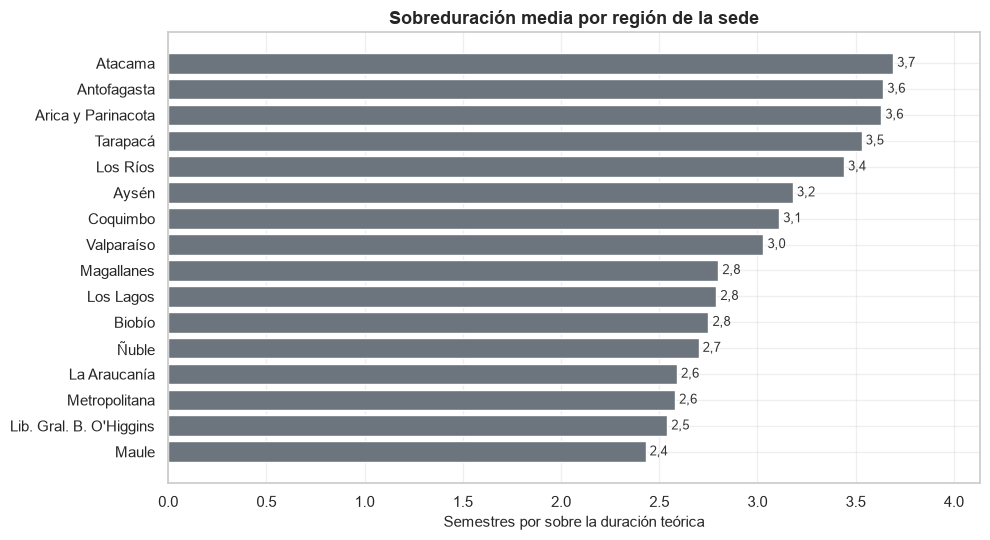

In [19]:
por_region = tr.tabla_agregada(df, "region_sede")
print(por_region.to_string(index=False))

fig = viz.barras(
    por_region.set_index("region_sede")["media"],
    "Sobreduración media por región de la sede",
    "Semestres por sobre la duración teórica",
    color=config.PALETA["neutro"],
    nombre_archivo="f2_3_sobreduracion_region",
)

> **Hallazgo 6.** La sobreduración es mayor en las regiones extremas del norte y
> del sur —Atacama (3,69), Antofagasta (3,64) y Arica y Parinacota (3,63)— y
> menor en Maule (2,43), O'Higgins (2,54) y la Región Metropolitana (2,58). La
> diferencia entre los extremos supera un semestre completo. La composición de la
> oferta explica parte del patrón: las regiones mineras concentran carreras
> técnicas y de ingeniería, que son precisamente las de mayor rezago.

## 5.7 Carreras con mayor y menor rezago

In [20]:
por_carrera = tr.tabla_agregada(df, "nomb_carrera", minimo_casos=3_000)

print("Mayor sobreduración (carreras con al menos 3.000 titulados):")
print(por_carrera.head(10).to_string(index=False))
print("\nMenor sobreduración:")
print(por_carrera.tail(10).to_string(index=False))

por_carrera.to_csv(config.TABLES_DIR / "f2_3_sobreduracion_por_carrera.csv", index=False)

Mayor sobreduración (carreras con al menos 3.000 titulados):
                                                            nomb_carrera  titulados  media  mediana  p25   p75  pct_oportuna
                                                   Prevencion de Riesgos       3480   7.57      6.0  1.0  13.0          19.3
                            Mecanica Automotriz en Sistemas Electronicos       5813   6.57      5.0  3.0   9.0           0.2
                                                                 Derecho      23808    6.4      5.0  3.0   9.0           4.2
                                                    Medicina Veterinaria       7458   5.02      4.0  2.0   7.0           7.7
                                                        Ingenieria Civil       3996   4.71      4.0  2.0   7.0           6.0
                                     Tecnico en Mantenimiento Industrial       5748   4.71      3.0  1.0   7.0           3.0
                Electricidad Industrial Mencion Instalaciones El

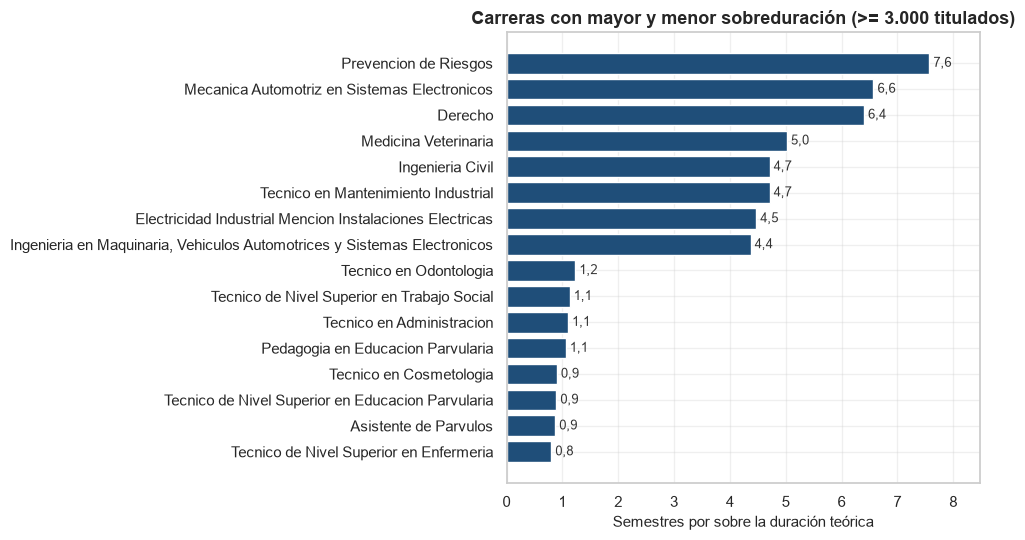

In [21]:
extremos = pd.concat([por_carrera.head(8), por_carrera.tail(8)])
fig = viz.barras(
    extremos.set_index("nomb_carrera")["media"],
    "Carreras con mayor y menor sobreduración (>= 3.000 titulados)",
    "Semestres por sobre la duración teórica",
    nombre_archivo="f2_3_carreras_extremas",
)

## 6. Exportación de tablas de resultados

Todas las tablas que sustentan el informe se guardan en `reports/tables/` para
que las cifras citadas sean verificables y reproducibles.

In [22]:
tablas = {
    "f2_3_indicadores_generales": indicadores,
    "f2_3_por_anio": por_anio,
    "f2_3_por_area": por_area,
    "f2_3_por_institucion": por_institucion,
    "f2_3_por_genero": por_genero,
    "f2_3_brecha_genero_area": brecha_area,
    "f2_3_por_modalidad": por_modalidad,
    "f2_3_perfil_modalidad": perfil_modalidad.reset_index(),
    "f2_3_por_region": por_region,
}
for nombre, tabla in tablas.items():
    tabla.to_csv(config.TABLES_DIR / f"{nombre}.csv", index=False)

figuras = sorted(p.name for p in config.FIGURES_DIR.glob("*.png"))
print(f"Tablas exportadas: {len(tablas)}")
print(f"Figuras generadas: {len(figuras)}")
for figura in figuras:
    print("  -", figura)

Tablas exportadas: 9
Figuras generadas: 17
  - f2_1_duracion_teorica.png
  - f2_1_titulados_por_anio.png
  - f2_1_titulados_por_area.png
  - f2_1_titulados_por_region.png
  - f2_2_categorias_rezago.png
  - f2_2_distribucion_sobreduracion.png
  - f2_2_teorica_vs_real.png
  - f2_3_carreras_extremas.png
  - f2_3_composicion_genero_area.png
  - f2_3_evolucion_no_presencial.png
  - f2_3_evolucion_oportuna.png
  - f2_3_evolucion_sobreduracion.png
  - f2_3_mapa_area_institucion.png
  - f2_3_oportuna_institucion.png
  - f2_3_sobreduracion_area.png
  - f2_3_sobreduracion_genero_area.png
  - f2_3_sobreduracion_region.png


## 7. Síntesis de hallazgos

| N.º | Hallazgo | Evidencia |
|-----|----------|-----------|
| H1 | Solo el 19,0 % de los titulados de pregrado egresa en el plazo teórico; la sobreduración media es de 2,76 semestres (índice 1,43). | Sección 5.1 |
| H2 | La titulación oportuna mejora de 15,2 % (2021) a 22,3 % (2025); 2020 muestra una caída de 27,4 % en el volumen de titulados. | Sección 5.2 |
| H3 | Derecho (5,77) y Ciencias Básicas (4,50) casi triplican la sobreduración de Educación (1,93). | Sección 5.3 |
| H4 | Las universidades promedian 3,32 semestres de rezago frente a 2,05 de los institutos profesionales. | Sección 5.3 |
| H5 | Las mujeres se titulan 0,94 semestres antes que los hombres, sin excepción en las diez áreas. | Sección 5.4 |
| H6 | La modalidad no presencial se triplica entre 2020 y 2025 y presenta menor rezago, pero con un perfil etario 10 años mayor. | Sección 5.5 |
| H7 | Las regiones extremas del norte superan en más de un semestre a las de menor rezago. | Sección 5.6 |

## 8. Limitaciones

1. **Sesgo de selección.** La base contiene únicamente a quienes se titularon.
   Las carreras con mayor deserción podrían mostrar una sobreduración
   artificialmente baja, porque los estudiantes más rezagados abandonan antes de
   titularse.
2. **Cambios de plan no observables.** Si un estudiante cambia de malla, la
   duración teórica registrada puede no ser la que efectivamente cursó.
3. **Registros descartados.** Se excluyó un 4,7 % de los registros de pregrado
   por carecer de año de ingreso utilizable; en su mayoría corresponden a
   estudiantes provenientes de otro programa o institución, cuyo tiempo total de
   estudios no es observable en esta fuente.
4. **Carácter descriptivo.** Las diferencias entre grupos son asociaciones, no
   efectos causales: no se controla por variables simultáneas.

## 9. Proyección a las fases siguientes

| Fase | Trabajo previsto | Insumo que aporta esta entrega |
|------|------------------|--------------------------------|
| F3 | Modelar la sobreduración (regresión) y la titulación oportuna (clasificación), con control multivariado de área, institución, modalidad, sexo y territorio. | `titulados_pregrado_analitico.parquet` con la variable objetivo ya construida y validada |
| F4 | Reporte analítico final y comunicación de hallazgos. | Catálogo de figuras y tablas reproducibles en `reports/` |

> **Fin de la Fase 2.**